In [13]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fetch live flights over Canada
url = "https://opensky-network.org/api/states/all"
params = {"lamin": 42, "lomin": -140, "lamax": 83, "lomax": -52}
response = requests.get(url, params=params)
data = response.json()

columns = ['icao24','callsign','origin_country','time_position',
           'last_contact','longitude','latitude','baro_altitude',
           'on_ground','velocity','true_track','vertical_rate',
           'sensors','geo_altitude','squawk','spi','position_source']

df = pd.DataFrame(data['states'], columns=columns)
print(df.shape)
df.head()

(1425, 17)


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,true_track,vertical_rate,sensors,geo_altitude,squawk,spi,position_source
0,a34230,EJA309,United States,1781989182,1781989182,-82.0549,43.1588,8534.40,False,196.51,261.72,0.00,None,8610.60,5733,False,0
1,c047e7,CGBFY,Canada,1781989183,1781989183,-79.6767,44.2806,1699.26,False,67.74,99.18,-0.65,None,1661.16,5302,False,0
2,ad5621,ALFT,United States,1781989173,1781989173,-122.7460,47.2015,342.90,False,62.38,176.22,2.60,None,342.90,NaN,False,0
3,c047d8,,Canada,1781989181,1781989181,-79.8693,43.7560,NaN,True,3.60,50.62,NaN,None,NaN,NaN,False,0
4,a89eb9,N65453,United States,1781989182,1781989182,-93.1424,45.3697,579.12,False,53.11,98.91,-0.33,None,571.50,NaN,False,0


<Axes: >

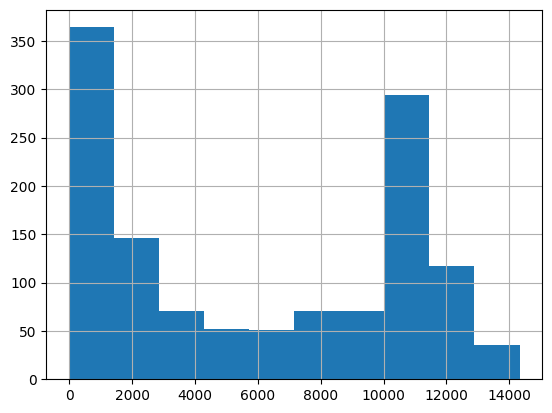

In [26]:
df['baro_altitude'].hist()

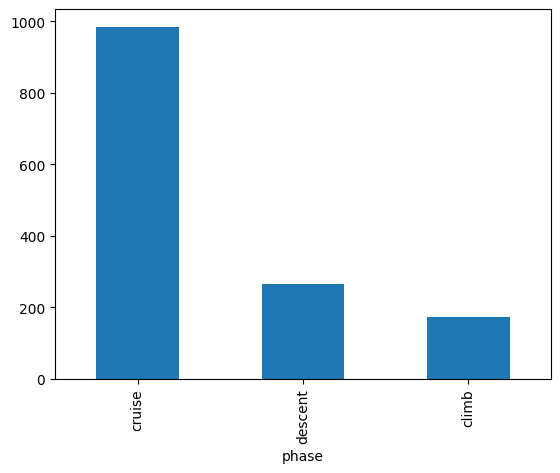

In [27]:
df['phase'].value_counts().plot(kind='bar')
plt.show()

<Axes: xlabel='baro_altitude', ylabel='velocity'>

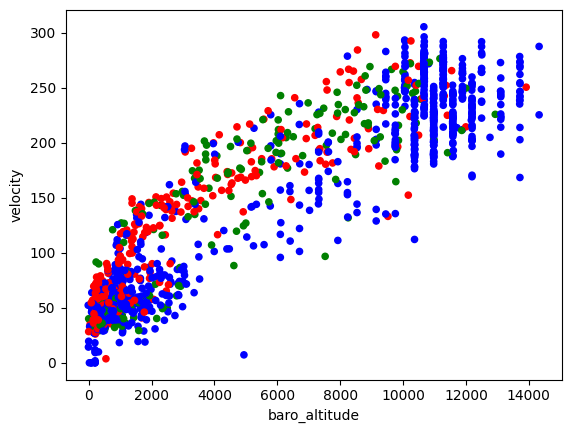

In [28]:
df.plot.scatter(x='baro_altitude', y='velocity', c=df['phase'].map({'climb':'green','cruise':'blue','descent':'red'}))

In [19]:
def label_phase(row):
    if row['vertical_rate'] > 2: return 'climb'
    if row['vertical_rate'] < -2: return 'descent'
    return 'cruise'

    

In [20]:
#cleaning and preproccesing data 
from sklearn.ensemble import RandomForestClassifier
df['phase'] = df.apply(label_phase, axis=1)
X = df[['baro_altitude', 'velocity']]
y= df['phase']






In [21]:
X.shape

(1425, 2)

In [22]:
#creat a pipleline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
pipeline = Pipeline(steps= [ ('imputer', SimpleImputer(strategy='mean') ),
    ('model', RandomForestClassifier())])

In [23]:
from sklearn.model_selection import cross_val_score

cross = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
print(cross.mean())


0.7263157894736842
